# 8. Pontos Fixos, Existência, Unicidade e Iteração

Na aula anterior estudamos mudanças qualitativas em sistemas dinâmicos. Agora iniciaremos a parte de **existência e unicidade** por uma ideia que será central na próxima aula: **pontos fixos**.

Dada uma função $g$, um número $p$ é ponto fixo quando

$$
\boxed{g(p)=p.}
$$

Geometricamente, pontos fixos de $g(x)$ podem ser vistos como interseções do gráfico das funções

$$
y=g(x)
\qquad\text{e}\qquad
y=x.
$$

Construiremos um algoritmo numérico para encontrar ponto fixos: a partir de $p_0$, definimos a sequência

$$
\boxed{p_{n+1}=g(p_n).}
$$

A pergunta central será:

> **Quando essa sequência converge? E, se converge, o limite é um ponto fixo?**

A aula segue a Seção 2.3 - Fixed Point Iteration Schemes do livro: **A Friendly Introduction to Numerical Analysis** de Brian Bradie . Na próxima aula, a mesma estrutura será usada para introduzir a iteração de Picard.

# Motivação
Em nosso contexto  o conceito de **ponto fixo**
é fundamental.

Considere o problema de valor inicial

$$
y'=f(x,y),
\qquad
y(x_0)=y_0.
$$

Integrando formalmente a equação entre $x_0$ e $x$, obtemos

$$
y(x)-y(x_0)
=
\int_{x_0}^{x} f(s,y(s))\,ds.
$$

Como $y(x_0)=y_0$, segue que

$$
\boxed{
y(x)
=
y_0+\int_{x_0}^{x} f(s,y(s))\,ds.
}
$$

Portanto, procurar uma solução do problema de valor inicial é equivalente a procurar uma função $y$ que permaneça inalterada pela transformação

$$
(Ty)(x)
=
y_0+\int_{x_0}^{x} f(s,y(s))\,ds.
$$

Isto é, queremos encontrar $y$ tal que

$$
\boxed{Ty=y.}
$$

Temos, assim, novamente um **problema de ponto fixo**, mas com uma diferença fundamental: agora o ``ponto'' fixo não é um número, e sim uma **função**.

Isso sugere uma pergunta natural:

> Se a ideia de ponto fixo funciona para números, será possível formulá-la em um espaço de funções de modo que possamos garantir a existência e a unicidade de uma solução do problema de valor inicial?

É essa ideia que retomaremos adiante, em um contexto matemático adequado.

# Se a iteração converge, qual é seu limite?
De volta ao contexto em que $g(x)$ é uma função real.
Suponha que
$$
p_{n+1}=g(p_n)
$$

e que

$$
p_n\to p.
$$

Se $g$ é contínua, então

$$
p
=
\lim_{n\to\infty}p_{n+1}
=
\lim_{n\to\infty}g(p_n)
=
g\left(\lim_{n\to\infty}p_n\right)
=
g(p).
$$

Logo,

$$
\boxed{g(p)=p.}
$$

Portanto, **se a iteração converge e $g$ é contínua, seu limite é necessariamente um ponto fixo**.

Isso não prova que a sequência converge. Observe que assumimos a
convergência a priori.

# Visualização geométrica — diagrama de teia

Partindo de $p_0$:

1. subimos verticalmente até $y=g(x)$, obtendo $p_1=g(p_0)$;
2. deslocamo-nos horizontalmente até $y=x$;
3. subimos ou descemos novamente até $y=g(x)$, obtendo $p_2=g(p_1)$;
4. repetimos.

O desenho resultante é conhecido como **diagrama de teia** (*cobweb diagram*).

Carrega primeiro as funções abaixo para depois desenhar o diagrama de teia de uma
função.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def iteracao_ponto_fixo(g, p0, n=10):
    pontos = [float(p0)]
    p = float(p0)
    for _ in range(n):
        p = float(g(p))
        pontos.append(p)
    return np.array(pontos)

def teia_ponto_fixo(g, p0, n=10, xmin=-1.5, xmax=1.5,
                    nome_funcao="g(x)", mostrar_valores=True):

    x = np.linspace(xmin, xmax, 1200)
    y = g(x)
    pontos = iteracao_ponto_fixo(g, p0, n)

    plt.figure(figsize=(8,8))
    plt.plot(x, y, linewidth=2, label=nome_funcao)
    plt.plot(x, x, "--", linewidth=1.5, label=r"$y=x$")

    p = float(p0)

    for i in range(n):
        q = float(g(p))

        # vertical: de (p,p) até (p,g(p))
        plt.plot([p,p], [p,q], linewidth=1.2)

        # horizontal: de (p,g(p)) até (g(p),g(p))
        plt.plot([p,q], [q,q], linewidth=1.2)

        # marca o iterado no eixo x
        plt.scatter([p], [0], s=18)

        p = q

    plt.scatter([p], [0], s=18)

    plt.xlim(xmin,xmax)
    plt.ylim(xmin,xmax)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(fr"Iteração de ponto fixo — $p_0={p0}$")
    plt.grid(alpha=.25)
    plt.legend()
    plt.show()

    if mostrar_valores:
        for i,p in enumerate(pontos):
            print(f"p_{i:2d} = {p:.12f}")

    return pontos

## Primeiro exemplo: $g(x)=\cos x$

Considere a função $g(x)=\cos x$ como exemplo. O ponto fixo (solução de
$g(x) = x$) é aproximadamente

$$
p\approx0.7390851332.
$$

Observe a geometria da iteração antes de fazer qualquer cálculo teórico.

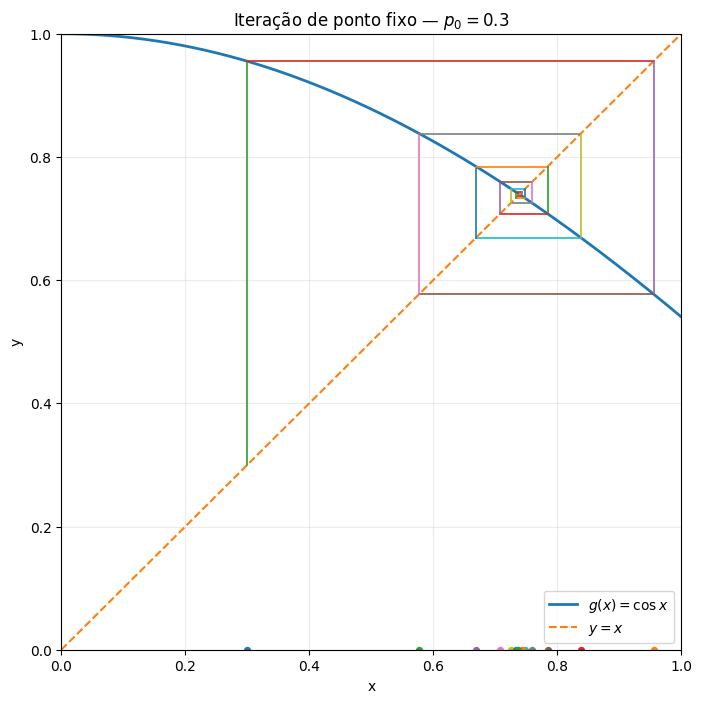

p_ 0 = 0.300000000000
p_ 1 = 0.955336489126
p_ 2 = 0.577334044471
p_ 3 = 0.837920683127
p_ 4 = 0.669009730822
p_ 5 = 0.784436224742
p_ 6 = 0.707786647276
p_ 7 = 0.759802755285
p_ 8 = 0.724971882754
p_ 9 = 0.748518067213
p_10 = 0.732698207892
p_11 = 0.743372339062
p_12 = 0.736190436401


array([0.3       , 0.95533649, 0.57733404, 0.83792068, 0.66900973,
       0.78443622, 0.70778665, 0.75980276, 0.72497188, 0.74851807,
       0.73269821, 0.74337234, 0.73619044])

In [3]:
g = lambda x: np.cos(x)

teia_ponto_fixo(
    g,
    p0=0.3,
    n=12,
    xmin=0,
    xmax=1,
    nome_funcao=r"$g(x)=\cos x$"
)

### Observe

- A sequência parece convergir?
- Os iterados alternam de um lado para outro do ponto fixo?
- A distância ao ponto fixo diminui?
- O que a inclinação de $g$ perto da interseção com $y=x$ parece ter a ver com a convergência?

# Existência de ponto fixo em um intervalo

## Teorema

Se

$$
g:[a,b]\to[a,b]
$$

é contínua, então existe pelo menos um $p\in[a,b]$ tal que

$$
g(p)=p.
$$

### Demonstração

Defina

$$
h(x)=g(x)-x.
$$

A função $h$ é contínua.

Como $g(a)\in[a,b]$,

$$
g(a)\geq a,
$$

logo

$$
h(a)=g(a)-a\geq0.
$$

Como $g(b)\in[a,b]$,

$$
g(b)\leq b,
$$

logo

$$
h(b)=g(b)-b\leq0.
$$

Se uma dessas desigualdades for igualdade, já temos um ponto fixo.

Caso contrário,

$$
h(a)>0,\qquad h(b)<0.
$$

Pelo Teorema do Valor Intermediário, existe $p\in(a,b)$ tal que

$$
h(p)=0.
$$

Assim,

$$
g(p)-p=0,
$$

portanto

$$
\boxed{g(p)=p.}
$$

## O que esse resultado ainda não garante?

Ele garante **existência**, mas não garante:

- unicidade;
- convergência da iteração;
- convergência a partir de qualquer $p_0$.

Para isso precisamos de uma condição que faça $g$ diminuir distâncias.

# Contrações

## Definição

Uma função $g:[a,b]\to\mathbb{R}$ é uma **contração** se existe

$$
0\leq k<1
$$

tal que

$$
\boxed{|g(x)-g(y)|\leq k|x-y|}
$$

para todos $x,y\in[a,b]$.

A constante $k$ mede a intensidade da contração.

## Critério pela derivada

Se $g$ é diferenciável e

$$
|g'(x)|\leq k<1
$$

para todo $x\in[a,b]$, então $g$ é uma contração.

### Demonstração

Pelo Teorema do Valor Médio, para $x,y\in[a,b]$ existe $\xi$ entre $x$ e $y$ tal que

$$
g(x)-g(y)=g'(\xi)(x-y).
$$

Tomando módulos,

$$
|g(x)-g(y)|
=
|g'(\xi)|\,|x-y|
\leq
k|x-y|.
$$

Logo $g$ é uma contração.

# Teorema de existência, unicidade e convergência

Suponha que

$$
g:[a,b]\to[a,b]
$$

seja diferenciável e que exista $k<1$ tal que

$$
|g'(x)|\leq k
$$

para todo $x\in[a,b]$.

Então:

1. $g$ possui um ponto fixo em $[a,b]$;
2. esse ponto fixo é único;
3. para qualquer $p_0\in[a,b]$, a sequência

$$
p_{n+1}=g(p_n)
$$

converge para ele.

# Demonstração da unicidade

Suponha que $p$ e $q$ sejam dois pontos fixos:

$$
g(p)=p,\qquad g(q)=q.
$$

Como $g$ é contração,

$$
|p-q|
=
|g(p)-g(q)|
\leq
k|p-q|.
$$

Portanto,

$$
(1-k)|p-q|\leq0.
$$

Como $1-k>0$,

$$
|p-q|=0,
$$

e assim

$$
\boxed{p=q.}
$$

# 8.8 Demonstração da convergência

Seja $p$ o ponto fixo único. Como $g([a,b])\subset[a,b]$, todos os iterados permanecem no intervalo.

Além disso,

$$
|p_{n+1}-p|
=
|g(p_n)-g(p)|
\leq
k|p_n-p|.
$$

Iterando essa desigualdade,

$$
|p_n-p|
\leq
k^n|p_0-p|.
$$

Como $0\leq k<1$,

$$
k^n\to0.
$$

Logo,

$$
\boxed{p_n\to p.}
$$

# Estimativa a priori do erro

Também podemos obter uma estimativa que não utiliza diretamente o ponto fixo.

Da propriedade de contração,

$$
|p_{j+1}-p_j|
\leq
k^j|p_1-p_0|.
$$

Além disso,

$$
p-p_n
=
\sum_{j=n}^{\infty}(p_{j+1}-p_j).
$$

Assim,

$$
|p-p_n|
\leq
\sum_{j=n}^{\infty}|p_{j+1}-p_j|
\leq
|p_1-p_0|\sum_{j=n}^{\infty}k^j.
$$

Como

$$
\sum_{j=n}^{\infty}k^j
=
\frac{k^n}{1-k},
$$

obtemos

$$
\boxed{
|p-p_n|
\leq
\frac{k^n}{1-k}|p_1-p_0|.
}
$$

Esse limite superior aparece na Seção 2.3 como ferramenta para controlar o número de iterações necessário.

# 8.10 A derivada no ponto fixo

Se $p$ é ponto fixo,

$$
g(p)=p.
$$

Pela expansão de Taylor,

$$
g(x)
=
p+g'(p)(x-p)+O((x-p)^2).
$$

Definindo

$$
e_n=p_n-p,
$$

temos, para $p_n$ próximo de $p$,

$$
\boxed{
e_{n+1}
\approx
g'(p)e_n.
}
$$

Isso explica três comportamentos (por quê?) :

$$
|g'(p)|<1
\quad\Longrightarrow\quad
\text{atração local},
$$

$$
|g'(p)|>1
\quad\Longrightarrow\quad
\text{repulsão local},
$$

enquanto $|g'(p)|=1$ é um caso no qual a aproximação linear não decide.

## O sinal da derivada também é visível

Se

$$
0<g'(p)<1,
$$

a aproximação tende a chegar ao ponto fixo sem alternar de lado.

Se

$$
-1<g'(p)<0,
$$

os iterados tendem a alternar entre os lados do ponto fixo.

É isso que acontece para $g(x)=\cos x$.

# Exemplo : $$g(x)=\frac12\cos x$$

No intervalo $[0,1]$:

$$
g(x)=\frac12\cos x
$$

é contínua.

Além disso,

$$
0<g(x)\leq\frac12,
$$

portanto

$$
g([0,1])\subset[0,1].
$$

A derivada é

$$
g'(x)=-\frac12\sin x.
$$

Logo,

$$
|g'(x)|
\leq
\frac12\sin1
<1.
$$

Assim, $g$ é uma contração em $[0,1]$.

Consequentemente:

$$
\boxed{\text{existe um único ponto fixo em }[0,1]}
$$

e, para qualquer $p_0\in[0,1]$, a iteração converge para ele.

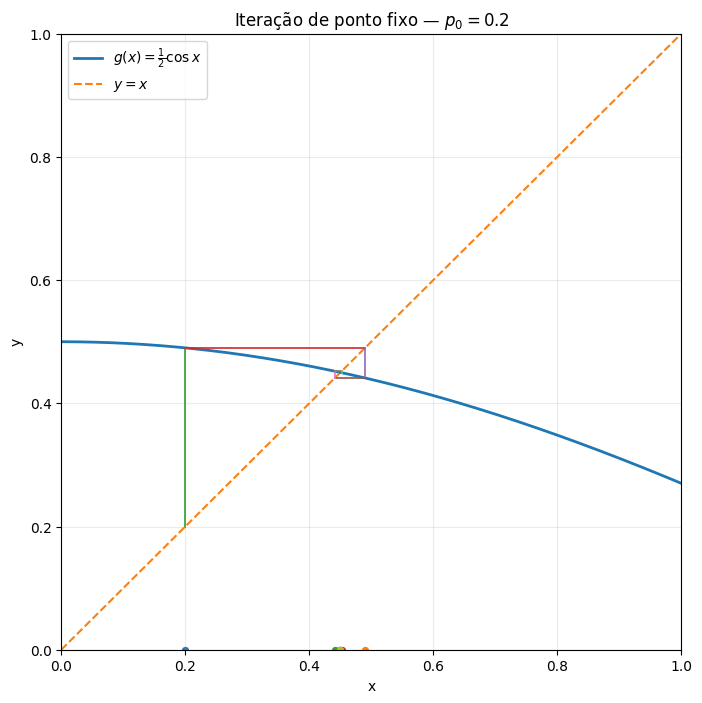

p_ 0 = 0.200000000000
p_ 1 = 0.490033288921
p_ 2 = 0.441158595747
p_ 3 = 0.452128782217
p_ 4 = 0.449759557937
p_ 5 = 0.450275830167
p_ 6 = 0.450163545742
p_ 7 = 0.450187976775
p_ 8 = 0.450182661513


array([0.2       , 0.49003329, 0.4411586 , 0.45212878, 0.44975956,
       0.45027583, 0.45016355, 0.45018798, 0.45018266])

In [4]:
g = lambda x: 0.5*np.cos(x)

teia_ponto_fixo(
    g,
    p0=0.2,
    n=8,
    xmin=0,
    xmax=1,
    nome_funcao=r"$g(x)=\frac{1}{2}\cos x$"
)

# Um ponto fixo pode existir e a iteração falhar

Considere

$$
g(x)=2x(1-x).
$$

Os pontos fixos são

$$
p=0
\qquad\text{e}\qquad
p=\frac12.
$$

Como

$$
g'(x)=2-4x,
$$

temos

$$
g'(0)=2,
$$

de modo que $0$ é repulsor para a iteração.

Por outro lado,

$$
g'\left(\frac12\right)=0,
$$

e $1/2$ é fortemente atrator.

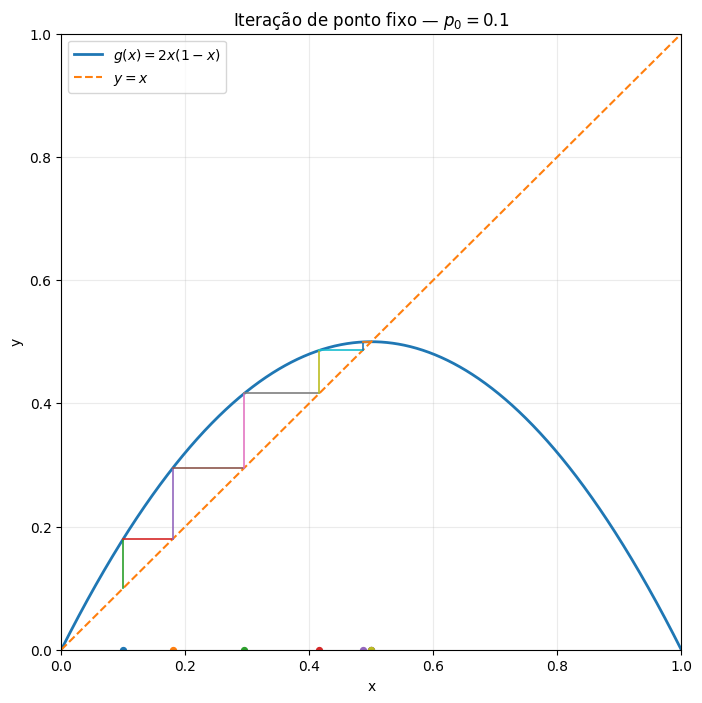

p_ 0 = 0.100000000000
p_ 1 = 0.180000000000
p_ 2 = 0.295200000000
p_ 3 = 0.416113920000
p_ 4 = 0.485926251164
p_ 5 = 0.499603859187
p_ 6 = 0.499999686145
p_ 7 = 0.500000000000
p_ 8 = 0.500000000000


array([0.1       , 0.18      , 0.2952    , 0.41611392, 0.48592625,
       0.49960386, 0.49999969, 0.5       , 0.5       ])

In [5]:
g = lambda x: 2*x*(1-x)

teia_ponto_fixo(
    g,
    p0=0.1,
    n=8,
    xmin=0,
    xmax=1,
    nome_funcao=r"$g(x)=2x(1-x)$"
)

Portanto,

$$
\boxed{
\text{existência de ponto fixo}
\not\Rightarrow
\text{convergência da iteração}.
}
$$

#  Programa interativo

Para investigar outra função, altere apenas

```python
g_interativa = lambda x: ...
nome_g = "..."
```

e execute novamente a célula.

In [7]:
from ipywidgets import interact, FloatSlider, IntSlider

# ALTERE A FUNÇÃO AQUI
g_interativa = lambda x: np.sqrt(x)
nome_g = r"$g(x)=\sqrt{x}$"

def visualizar_interativo(p0=0.0, n=10, xmin=0.0, xmax=2.0):
    teia_ponto_fixo(
        g_interativa,
        p0,
        n=n,
        xmin=xmin,
        xmax=xmax,
        nome_funcao=nome_g,
        mostrar_valores=False
    )

interact(
    visualizar_interativo,
    p0=FloatSlider(value=0.0, min=-1.5, max=1.5, step=.05,
                   description="p0"),
    n=IntSlider(value=10, min=1, max=40, step=1,
                description="n"),
    xmin=FloatSlider(value=0.0, min=-3, max=1, step=.1,
                     description="xmin"),
    xmax=FloatSlider(value=1.0, min=.5, max=3, step=.1,
                     description="xmax")
);

interactive(children=(FloatSlider(value=0.0, description='p0', max=1.5, min=-1.5, step=0.05), IntSlider(value=…

# 8.18 Algoritmo numérico básico

A função abaixo implementa a iteração e usa como critério computacional

$$
|p_{n+1}-p_n|<\varepsilon.
$$

Esse critério é simples, mas deve ser interpretado com cuidado: em convergência linear, a diferença entre iterados não é necessariamente igual ao erro verdadeiro.

In [ ]:
def ponto_fixo(g, p0, tol=1e-8, nmax=100):
    p = float(p0)

    for n in range(1,nmax+1):
        novo = float(g(p))

        if abs(novo-p) < tol:
            return novo,n

        p = novo

    raise RuntimeError("Número máximo de iterações excedido.")

g = lambda x: np.cos(x)

p,n = ponto_fixo(g,0.0,tol=1e-10)

print("aproximação =",p)
print("iterações   =",n)

aproximação = 0.7390851332451103
iterações   = 59


# 8.19 Conexão com estabilidade

A iteração

$$
p_{n+1}=g(p_n)
$$

é uma dinâmica discreta.

Um ponto fixo satisfaz

$$
g(p)=p.
$$

Sua estabilidade local é controlada por $g'(p)$.

Compare com a EDO autônoma

$$
\dot{x}=f(x),
$$

na qual um equilíbrio satisfaz

$$
f(x^*)=0
$$

e, quando $f'(x^*)\neq0$, a estabilidade é determinada pelo sinal de $f'(x^*)$.

Os problemas são diferentes, mas a filosofia é a mesma:

> **estudamos a dinâmica perto de um estado especial por meio da aproximação linear.**

# Exercícios

### 1. $g(x)=\frac12\cos x$

Mostre rigorosamente que $g$ possui um único ponto fixo em $[0,1]$ e que a iteração converge para ele para qualquer $p_0\in[0,1]$.

### 2. $g(x)=e^{-x^2}$

No intervalo $[0,1]$:

1. prove que $g([0,1])\subset[0,1]$;
2. encontre $k<1$ com $|g'(x)|\leq k$;
3. conclua existência, unicidade e convergência;
4. compare com o visualizador.

### 3. $g(x)=2x(1-x)$

Mostre que $0$ e $1/2$ são pontos fixos e explique a diferença entre eles usando $g'$.

### 4. $g(x)=1+x-\frac18x^3$

1. Mostre que $p=2$ é o único ponto fixo real.
2. Calcule $g'(2)$.
3. Que ordem de convergência local você espera?
4. Faça sete iterações a partir de $p_0=0$.

### 5. Iteração para $\sqrt a$

Considere

$$
g(x)=\frac12\left(x+\frac ax\right).
$$

Mostre que $\sqrt a$ é ponto fixo e calcule $g'(\sqrt a)$ e $g''(\sqrt a)$. Determine a ordem esperada da convergência.

### 6. Duas reformulações

Para

$$
f(x)=e^x+x^2-x-4,
$$

encontre duas formas $x=g(x)$ correspondentes à equação $f(x)=0$. Use derivadas e o visualizador para comparar as iterações no intervalo $(1,2)$.

### 7. Geometria da iteração

Desenhe à mão diagramas de teia para:

$$
0<g'(p)<1,
$$

$$
-1<g'(p)<0,
$$

$$
g'(p)>1,
$$

e

$$
g'(p)<-1.
$$

### 8. Demonstração

Prove

$$
|p_n-p|\leq k^n|p_0-p|.
$$

### 9. Estimativa a priori

Demonstre

$$
|p-p_n|
\leq
\frac{k^n}{1-k}|p_1-p_0|.
$$

### 10. Investigação

Escolha uma função com ponto fixo e procure condições iniciais ou reformulações que produzam:

- convergência rápida;
- convergência lenta;
- ausência de convergência.

Explique o resultado matematicamente.